# Exercise 1

In [1]:
from pathlib import Path
from amocatlas import read

from amoc_analysis import data, plotting

import pandas as pd

## Load and plot the RAPID component data using amocatlas

In [2]:
# Load RAPID dataset
ds = read.rapid()
print(ds)

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

<xarray.Dataset> Size: 1MB
Dimensions:           (TIME: 14599)
Coordinates:
  * TIME              (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    TRANS_0_800       (TIME) float64 117kB ...
    TRANS_800_1100    (TIME) float64 117kB ...
    TRANS_1100_3000   (TIME) float64 117kB ...
    TRANS_3000_5000   (TIME) float64 117kB ...
    TRANS_below_5000  (TIME) float64 117kB ...
    TRANS_FC          (TIME) float64 117kB ...
    TRANS_EKMAN       (TIME) float64 117kB ...
    TRANS_UMO         (TIME) float64 117kB ...
    MOC               (TIME) float64 117kB ...
Attributes: (12/39)
    title:                                 RAPID MOC timeseries
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:          

## Plot the time series and visually evaluate them

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'RAPID 26°N - AMOC Transport'}, xlabel='Time', ylabel='$MOC_z$ [Sverdrup]'>)

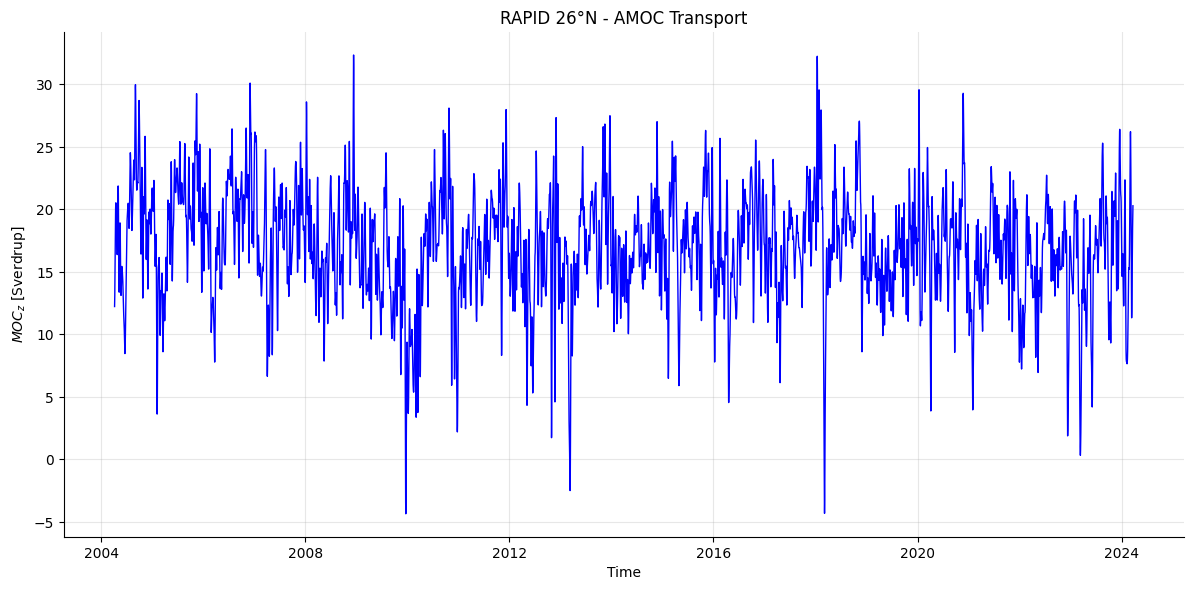

In [3]:
fig, ax = plotting.plot_time_series(ds, 'MOC')

ax.set_ylabel(r'$MOC_z$ [Sverdrup]')
ax.set_title(r'RAPID 26°N - AMOC Transport')

fig, ax

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'RAPID 26°N - AMOC Transport'}, xlabel='Time', ylabel='$MOC_z$ [Sverdrup]'>)

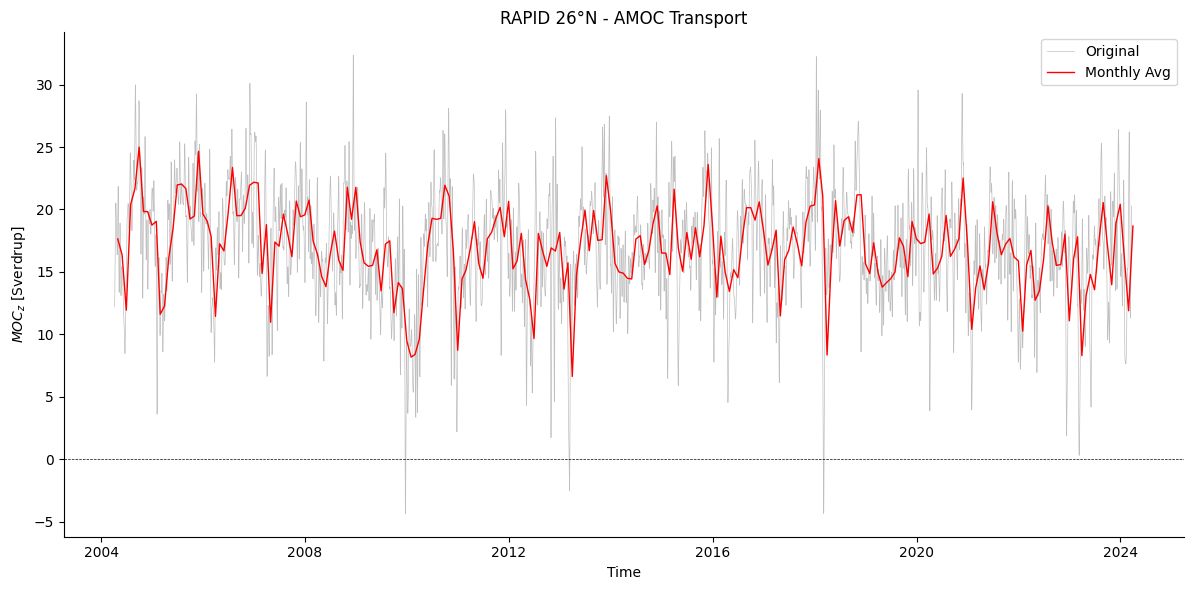

In [4]:
fig, ax = plotting.plot_monthly_transport(ds, 'MOC')

ax.set_ylabel(r'$MOC_z$ [Sverdrup]')

fig, ax

## Calculate basic statistics

mean, std

In [5]:
365/2

182.5

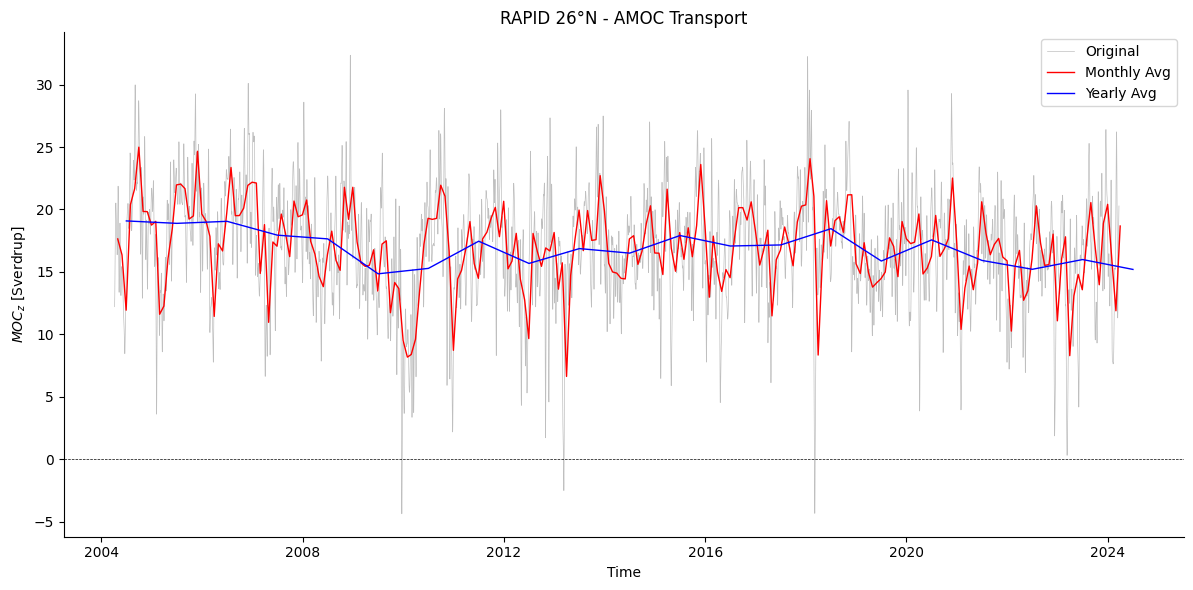

<xarray.Dataset> Size: 2kB
Dimensions:           (TIME: 21)
Coordinates:
  * TIME              (TIME) datetime64[ns] 168B 2004-01-01 ... 2024-01-01
Data variables:
    TRANS_0_800       (TIME) float64 168B -18.19 -16.07 -16.68 ... -18.57 -18.31
    TRANS_800_1100    (TIME) float64 168B 0.3785 0.7727 0.6947 ... 0.5258 0.2215
    TRANS_1100_3000   (TIME) float64 168B -12.94 -11.87 -11.67 ... -12.16 -11.75
    TRANS_3000_5000   (TIME) float64 168B -6.849 -7.687 -7.839 ... -4.912 -4.581
    TRANS_below_5000  (TIME) float64 168B 0.8932 0.785 0.6048 ... 1.289 1.389
    TRANS_FC          (TIME) float64 168B 32.85 31.01 31.33 ... 30.57 30.69
    TRANS_EKMAN       (TIME) float64 168B 3.866 3.074 3.566 ... 4.011 3.26 2.346
    TRANS_UMO         (TIME) float64 168B -17.6 -15.18 -15.83 ... -17.74 -17.79
    MOC               (TIME) float64 168B 19.08 18.89 19.05 ... 15.22 16.0 15.2
Attributes: (12/39)
    title:                                 RAPID MOC timeseries
    summary:                     

In [6]:
import matplotlib.pyplot as plt

var = 'MOC'

# Calculate mean
ds_yearly = ds.resample(TIME="YS").mean()   # year start
# ds_yearly = ds.resample(TIME="YE").mean()   # year end
# ds_yearly = ds.resample(TIME="Y").mean()   # year

ds_yearly.TIME + pd.Timedelta('182.5day')


# Plot original data and monthly averages
fig, ax = plotting.plot_monthly_transport(ds, 'MOC')

# Plot yearly averages
ax.plot(
    # ds_yearly.TIME,
    ds_yearly.TIME + pd.Timedelta('182.5day'),
    ds_yearly[var],
    color="blue",
    linewidth=1.0,
    label="Yearly Avg",
)

# Fig settings
ax.set_ylabel(r'$MOC_z$ [Sverdrup]')
ax.legend()

plt.show()

print(ds_yearly)

In [7]:
# Calculate standard deviation
std_MOC = ds['MOC'].std()

print(std_MOC)

<xarray.DataArray 'MOC' ()> Size: 8B
array(4.40175195)
Attributes:
    long_name:      MOC_z
    units:          Sverdrup
    description:    MOC strength
    standard_name:  ocean_meridional_overturning_transport
